![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras.layers import Dense, Activation
from livelossplot import PlotLossesKeras
from keras import initializers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

In [ ]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


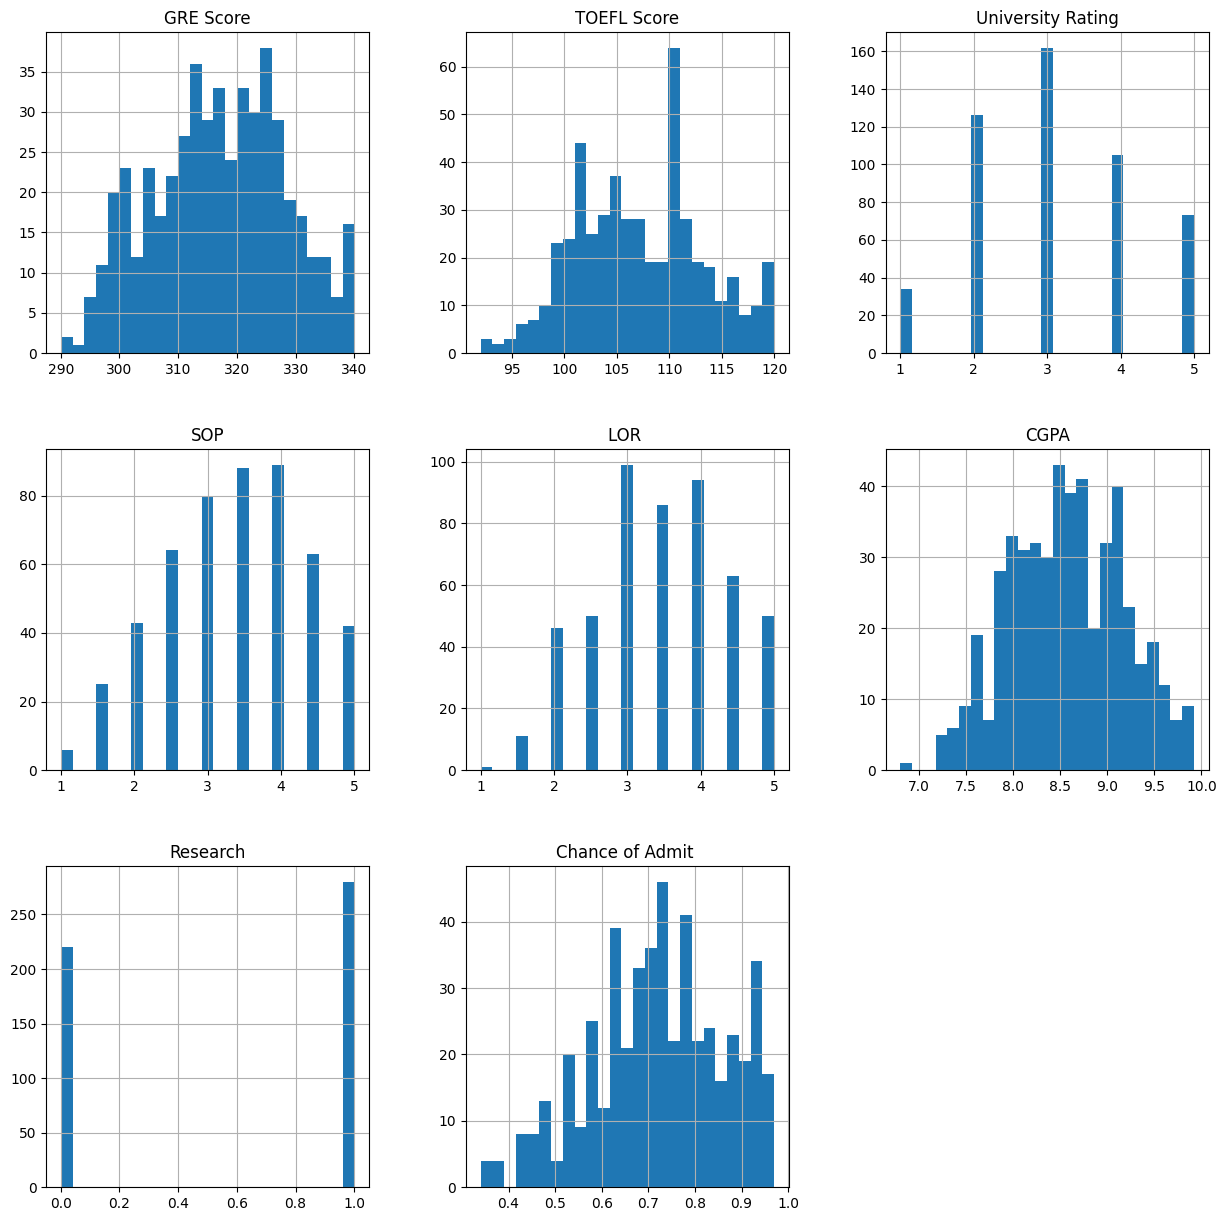

In [ ]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [ ]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [ ]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

In [ ]:
# ── ESCALAMIENTO DE VARIABLES (PASO CRÍTICO) ──────────────────────────────────
# Las variables tienen rangos muy distintos:
#   GRE Score:   290-340  (rango ~50)
#   TOEFL Score:  92-120  (rango ~28)
#   CGPA:         6.8-9.9 (rango ~3)
#   Research:     0 o 1   (binaria)
# Sin escalar, las neuronas se ven dominadas por GRE/TOEFL, perjudicando el aprendizaje.
# StandardScaler lleva cada variable a media=0, desviación estándar=1.

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

scaler = StandardScaler()
# fit SOLO en train
xTrain_scaled = scaler.fit_transform(xTrain)  
# transform en test con los parámetros de train 
xTest_scaled  = scaler.transform(xTest)        

print('Escalamiento completado:')
print(f'  Media (train escalado): {xTrain_scaled.mean(axis=0).round(2)}')
print(f'  Std  (train escalado): {xTrain_scaled.std(axis=0).round(2)}')

Escalamiento completado:
  Media (train escalado): [ 0.  0. -0. -0.  0.  0.  0.]
  Std  (train escalado): [1. 1. 1. 1. 1. 1. 1.]


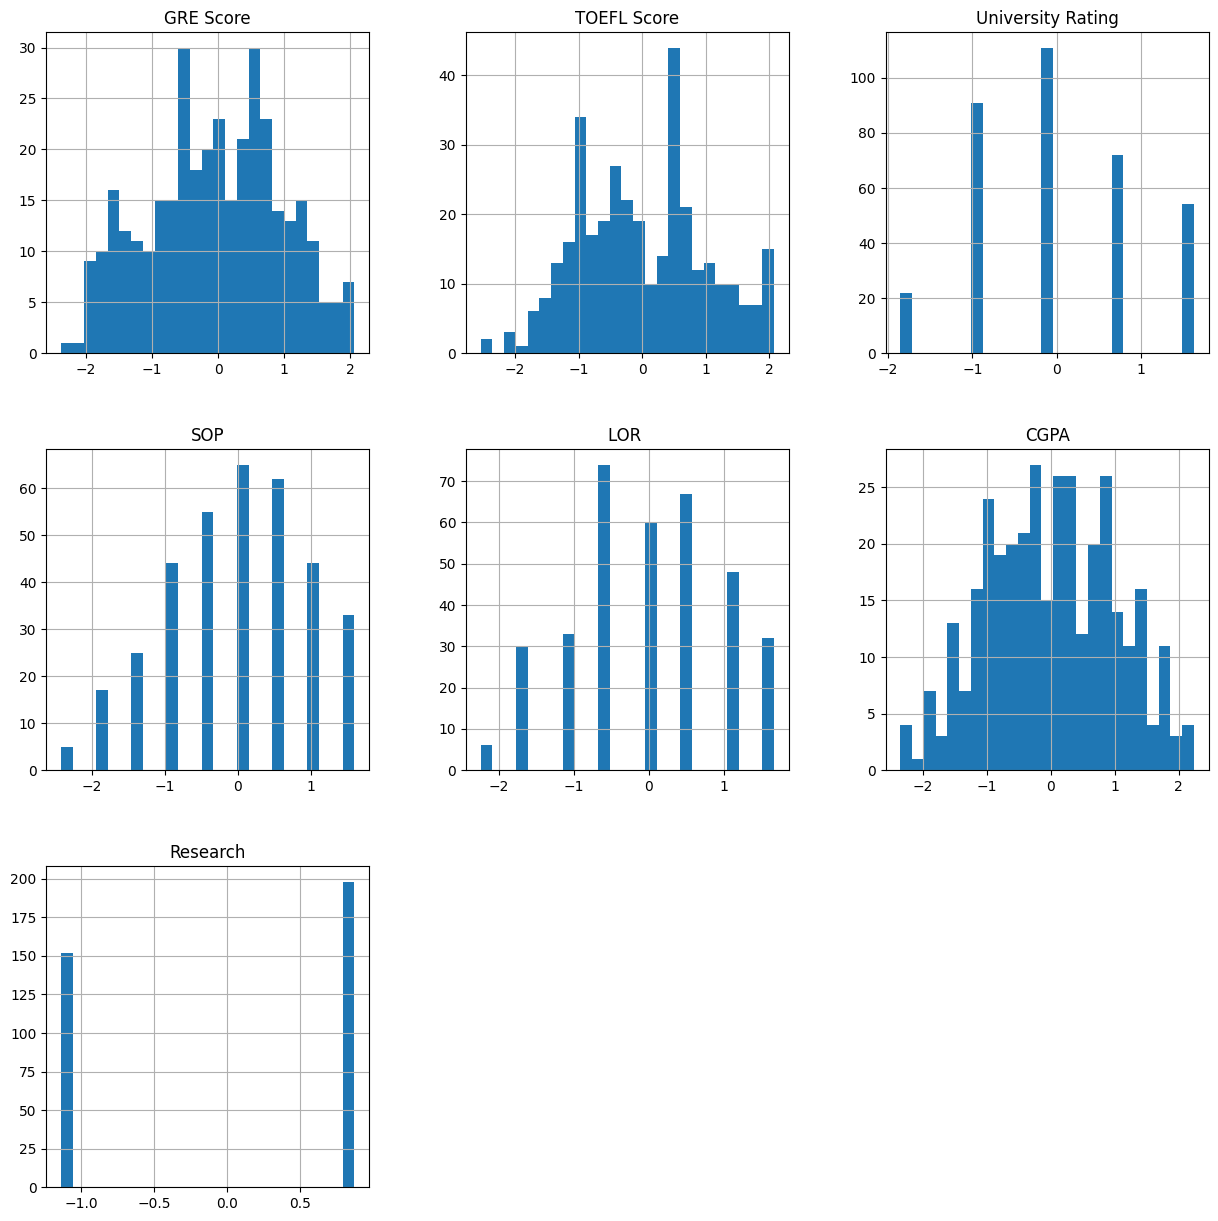

In [ ]:
xTrain_with_scaling = pd.DataFrame(xTrain_scaled, columns=xTrain.columns)
xTrain_with_scaling.hist(bins=25, figsize=(15,15))
plt.show()

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [ ]:
# Celda 1

# Definición red neuronal con la función Sequential()
model0 = Sequential()
# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model0.add(Dense(1, input_shape=(xTrain_scaled.shape[1],)))

# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model0.compile(optimizer='sgd', loss='mse')

# Impresión de la arquitectura de la red neuronal
print(model0.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 8         
                                                                 
Total params: 8
Trainable params: 8
Non-trainable params: 0
_________________________________________________________________
None


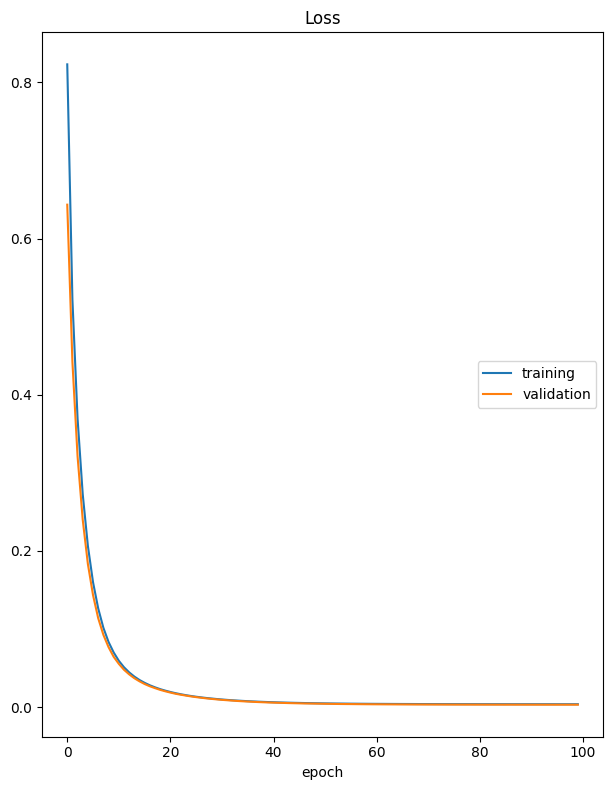

Loss
	training         	 (min:    0.004, max:    0.823, cur:    0.004)
	validation       	 (min:    0.003, max:    0.643, cur:    0.003)
11/11 [==============================] - 0s 11ms/step - loss: 0.0038 - val_loss: 0.0032
Model 3 | MAE = 0.0415  |  MSE = 0.003158


In [ ]:
# Entrenamiento de la red neuronal con 50 épocas
model0.fit(xTrain_scaled, yTrain, 
          verbose=1, 
          epochs=100, 
          validation_data=(xTest_scaled, yTest),
          callbacks=[PlotLossesKeras()])


# Métricas en test
yPred0 = model0.predict(xTest_scaled, verbose=0).flatten()
mae0 = mean_absolute_error(yTest, yPred0)
mse0 = mean_squared_error(yTest, yPred0)
print(f'Model 3 | MAE = {mae0:.4f}  |  MSE = {mse0:.6f}')

- Una sola capa densa con 1 neurona de salida y sin función de activación. Matemáticamente equivalente a una regresión lineal.
- Optimizador SGD (Stochastic Gradient Descent): más simple y robusto por defecto; sirve como punto de partida sin ajuste fino.
- Solo puede aprender relaciones lineales, si GRE sube, la probabilidad sube en proporción fija, sin interacciones entre variables.
- Función de referencia: si ningún modelo más complejo supera este resultado, agregar capas no está justificado.

In [ ]:

# Celda 1 — Red neuronal de UNA capa oculta
# Justificación:
#   - Una capa densa con 16 neuronas y activación ReLU es suficiente para comenzar.
#   - Optimizador Adam: adaptativo y robusto sin necesidad de ajustar la tasa de aprendizaje.
#   - Función de pérdida MSE: adecuada para regresión continua (probabilidad 0-1).
#   - 150 épocas: suficiente para converger sin sobreajuste evidente en un modelo simple.

model1 = Sequential([
    Dense(16, activation='relu', input_shape=(xTrain_scaled.shape[1],)),
    Dense(1,  activation='linear')   
])
model1.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model1.summary()

hist1 = model1.fit(
    xTrain_scaled, yTrain,
    epochs=150, batch_size=32,
    validation_split=0.2,
    verbose=0
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 16)                128       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 145
Trainable params: 145
Non-trainable params: 0
_________________________________________________________________


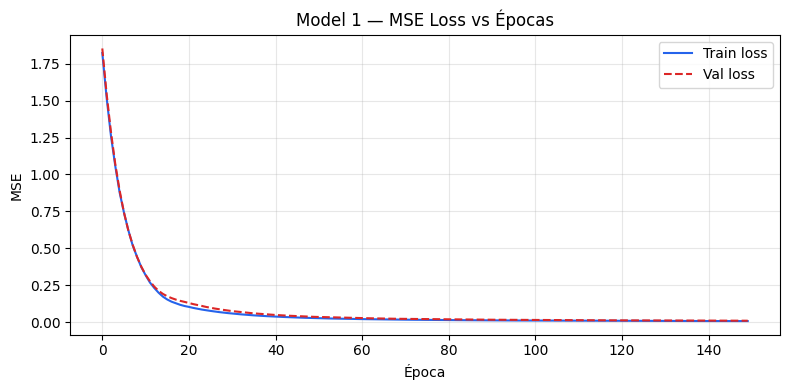

Model 1 | MAE = 0.0879  |  MSE = 0.011846


In [ ]:
# Gráfica de pérdida vs épocas
plt.figure(figsize=(8,4))
plt.plot(hist1.history['loss'],     label='Train loss', color='#2563EB')
plt.plot(hist1.history['val_loss'], label='Val loss',   color='#DC2626', linestyle='--')
plt.title('Model 1 — MSE Loss vs Épocas'); plt.xlabel('Época'); plt.ylabel('MSE')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Métricas en test
yPred1 = model1.predict(xTest_scaled, verbose=0).flatten()
mae1 = mean_absolute_error(yTest, yPred1)
mse1 = mean_squared_error(yTest, yPred1)
print(f'Model 1 | MAE = {mae1:.4f}  |  MSE = {mse1:.6f}')

- Cambio clave respecto al **modelo 0**: se agrega activación ReLU. El modelo ahora puede capturar relaciones no lineales.
- `16` neuronas: intencionalmente para iniciar como primer acercamiento para un modelo no lineal.
- `150` épocas (vs `100` en **M0**): más ciclos para que el modelo encuentre patrones significativos con la nueva capacidad no lineal.
- **MAE** sube a `0.0879` y **MSE** a `0.011846` — peor que **M0** en este dataset pequeño; evidencia de que más capacidad no siempre mejora en datos limitados sin regularización.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [ ]:
# Celda 2
# Celda 2 — Red neuronal con DOS capas ocultas
# Justificación:
#   - Primera capa (64 neuronas): mayor capacidad de extracción de patrones no lineales.
#   - Segunda capa (32 neuronas): refinamiento progresivo (embudo) de la representación.
#   - ReLU evita el vanishing gradient y acelera el entrenamiento.
#   - Adam + MSE: misma lógica que Modelo 1 para comparación justa.
model2 = Sequential([
    Dense(64, activation='relu', input_shape=(xTrain_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1,  activation='linear')
])
model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
model2.summary()

hist2 = model2.fit(
    xTrain_scaled, yTrain,
    epochs=150, batch_size=32,
    validation_split=0.2,
    verbose=0
)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                512       
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2,625
Trainable params: 2,625
Non-trainable params: 0
_________________________________________________________________


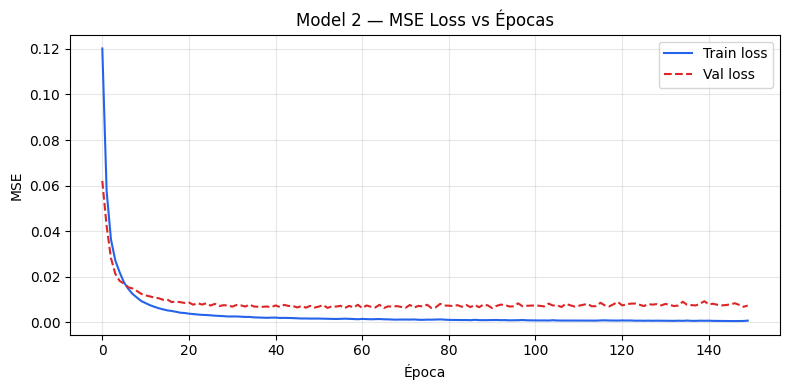

Model 2 | MAE = 0.0707  |  MSE = 0.008323


In [ ]:
# Gráfica de pérdida vs épocas
plt.figure(figsize=(8,4))
plt.plot(hist2.history['loss'],     label='Train loss', color='#2563EB')
plt.plot(hist2.history['val_loss'], label='Val loss',   color='#DC2626', linestyle='--')
plt.title('Model 2 — MSE Loss vs Épocas'); plt.xlabel('Época'); plt.ylabel('MSE')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Métricas en test
yPred2 = model2.predict(xTest_scaled, verbose=0).flatten()
mae2 = mean_absolute_error(yTest, yPred2)
mse2 = mean_squared_error(yTest, yPred2)
print(f'Model 2 | MAE = {mae2:.4f}  |  MSE = {mse2:.6f}')

- Se agrega una segunda capa oculta: arquitectura de embudo (funnel): 64 neuronas capturan patrones amplios, 32 comprimen y refinan.
- Optimizador, pérdida y épocas idénticos a **M1** — el único cambio es la arquitectura, haciendo la comparación directamente interpretable.
- Mayor capacidad para detectar interacciones complejas entre múltiples variables simultáneamente.
- **MAE** mejora a `0.0707` y MSE a `0.008323` comparando respecto a **M1**, confirma que la profundidad ayuda cuando se usa correctamente.

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [ ]:
# Celda 3 — Red multicapa con Early Stopping y Dropout
# Justificación:
#   - Arquitectura más profunda (128→64→32) para mayor capacidad expresiva.
#   - Dropout(0.3) y Dropout(0.2): regularización para reducir sobreajuste.
#   - EarlyStopping (patience=15, restore_best_weights=True):
#       detiene el entrenamiento cuando val_loss deja de mejorar,
#       evitando sobreajuste y desperdicio computacional.
#   - 300 épocas máximo: suficiente margen para que ES actúe.

from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model3 = Sequential([
    Dense(128, activation='relu', input_shape=(xTrain_scaled.shape[1],)),
    Dropout(0.5),
    Dense(64,  activation='relu'),
    Dropout(0.5),
    Dense(32,  activation='relu'),
    Dense(1,   activation='linear')
])
model3.compile(optimizer='adam', loss='mse', metrics=['mae'])
model3.summary()

hist3 = model3.fit(
    xTrain_scaled, yTrain,
    epochs=300, batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=0
)
print(f'Entrenamiento detenido en época: {len(hist3.history["loss"])}')


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 128)               1024      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 1)                 33        
                                                                 
Total params: 11,393
Trainable params: 11,393
Non-trai

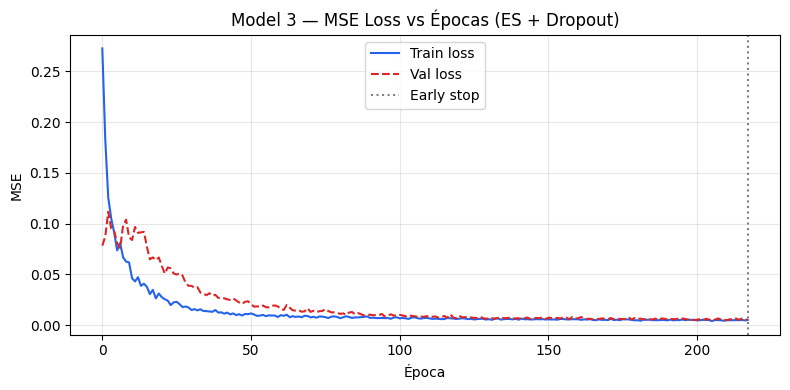

Model 3 | MAE = 0.0554  |  MSE = 0.004872


In [ ]:
# Gráfica de pérdida vs épocas
plt.figure(figsize=(8,4))
plt.plot(hist3.history['loss'],     label='Train loss', color='#2563EB')
plt.plot(hist3.history['val_loss'], label='Val loss',   color='#DC2626', linestyle='--')
plt.axvline(len(hist3.history['loss'])-1, color='gray', linestyle=':', label='Early stop')
plt.title('Model 3 — MSE Loss vs Épocas (ES + Dropout + 300 epoch)')
plt.xlabel('Época'); plt.ylabel('MSE')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Métricas en test
yPred3 = model3.predict(xTest_scaled, verbose=0).flatten()
mae3 = mean_absolute_error(yTest, yPred3)
mse3 = mean_squared_error(yTest, yPred3)
print(f'Model 3 | MAE = {mae3:.4f}  |  MSE = {mse3:.6f}')

- Tres capas ocultas (128 -> 64 -> 32): mayor capacidad para interacciones complejas.
- Dropout `50%`: durante cada paso de entrenamiento se apagan aleatoriamente la mitad de las neuronas, fuerza al modelo a aprender representaciones redundantes y evitar memorizar datos.
- **Early Stopping**: monitorea la pérdida de validación y detiene automáticamente cuando no mejora en 15 épocas consecutivas; restaura los mejores pesos encontrados.
- El límite de `300` épocas es un techo de seguridad. El Early Stopping actuó en la época `218`.
- Dropout del `50%` es agresivo para un dataset pequeño: introduce demasiado ruido, lo que explica por qué **M3** (**MAE** `0.0554`) no supera a **M2** (**MAE** `0.0707`) tanto como cabría esperar de mayor profundidad.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

model4 = Sequential([
    Dense(128, activation='relu', input_shape=(xTrain_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.2),
    Dense(32,  activation='relu'),
    Dense(1,   activation='linear')
])
model4.compile(optimizer='adam', loss='mse', metrics=['mae'])
model4.summary()

hist4 = model4.fit(
    xTrain_scaled, yTrain,
    epochs=600, batch_size=32,
    validation_split=0.2,
    callbacks=[es],
    verbose=0
)
print(f'Entrenamiento detenido en época: {len(hist4.history["loss"])}')

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 128)               1024      
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_12 (Dense)            (None, 32)                2080      
                                                                 
 dense_13 (Dense)            (None, 1)                 33        
                                                                 
Total params: 11,393
Trainable params: 11,393
Non-trai

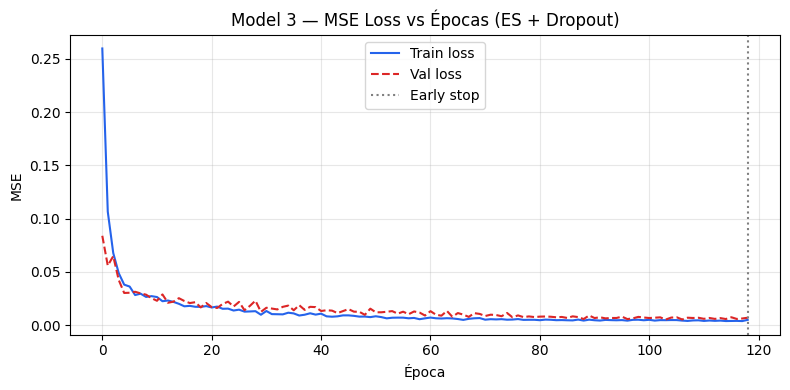

Model 3 | MAE = 0.0554  |  MSE = 0.004872


In [ ]:
# Gráfica de pérdida vs épocas
plt.figure(figsize=(8,4))
plt.plot(hist4.history['loss'],     label='Train loss', color='#2563EB')
plt.plot(hist4.history['val_loss'], label='Val loss',   color='#DC2626', linestyle='--')
plt.axvline(len(hist4.history['loss'])-1, color='gray', linestyle=':', label='Early stop')
plt.title('Model 3 — MSE Loss vs Épocas (ES + Dropout + 600 epch)')
plt.xlabel('Época'); plt.ylabel('MSE')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Métricas en test
yPred4 = model4.predict(xTest_scaled, verbose=0).flatten()
mae4 = mean_absolute_error(yTest, yPred4)
mse4 = mean_squared_error(yTest, yPred4)
print(f'Model 4 | MAE = {mae4:.4f}  |  MSE = {mse4:.6f}')

- Arquitectura idéntica a **M3** (128 -> 64 -> 32); dos cambios deliberados: reducir dropout y ampliar techo de épocas.
- Dropout reducido: primera capa de `50%` a `30%`, segunda capa de `50%` a `20%`. Regularización más calibrada que retiene más información durante el entrenamiento.
- `600` épocas máximo (vs `300` en **M3**): con menos dropout el modelo converge más suavemente y puede necesitar más épocas para estabilizarse.
- Resultado: **MAE** `0.0558` vs `0.0554` de **M3** prácticamente idénticos; confirma que el dropout más bajo no deteriora pero tampoco cambia radicalmente el resultado en este dataset.
- La diferencia **M3** vs **M4** ilustra directamente el impacto del dropout: demasiado agresivo (**50%**) introduce ruido excesivo; calibrado (**30/20%**) preserva el aprendizaje sin sobreajuste.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

Modelo                           MAE            MSE
-------------------------------------------------------
Model 0 (1 capa - Lineal)     0.0415       0.003158
Model 1 (1 capa)              0.0879       0.011846
Model 2 (2 capas)             0.0707       0.008323
Model 3 (300-eph+ES+Dropout)     0.0554       0.004872
Model 4 (600-eph+ES+Dropout)     0.0558       0.004832


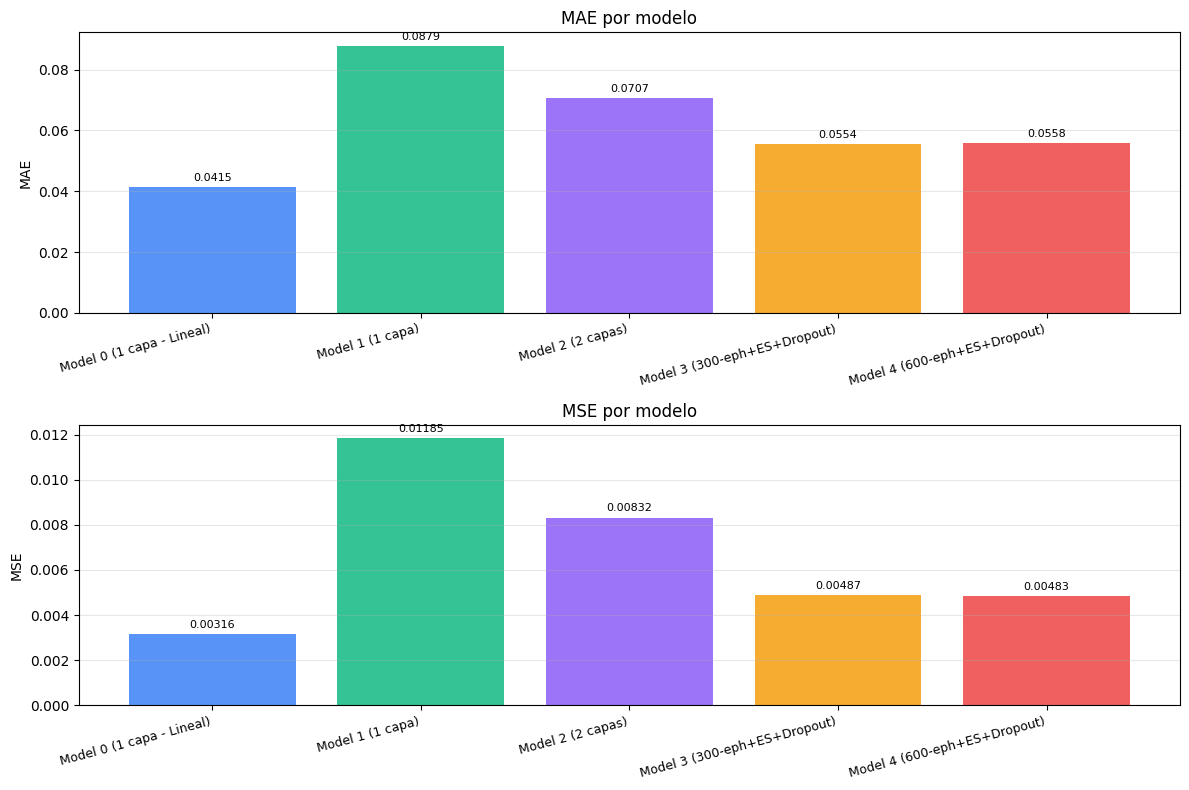

In [ ]:
# Celda 4

import numpy as np

metrics = {
    'Model 0 (1 capa - Lineal)':  {'MAE': mae0, 'MSE': mse0},
    'Model 1 (1 capa)':           {'MAE': mae1, 'MSE': mse1},
    'Model 2 (2 capas)':          {'MAE': mae2, 'MSE': mse2},
    'Model 3 (300-eph+ES+Dropout)':       {'MAE': mae3, 'MSE': mse3},
    'Model 4 (600-eph+ES+Dropout)':       {'MAE': mae4, 'MSE': mse4},
    
}

print('='*55)
print(f'{"Modelo":<25} {"MAE":>10} {"MSE":>14}')
print('-'*55)
for m, v in metrics.items():
    print(f'{m:<25} {v["MAE"]:>10.4f} {v["MSE"]:>14.6f}')
print('='*55)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
names = list(metrics.keys())
maes_ = [v['MAE'] for v in metrics.values()]
mses_ = [v['MSE'] for v in metrics.values()]

b1 = axes[0].bar(names, maes_, color=['#3B82F6','#10B981','#8B5CF6','#F59E0B','#EF4444'], alpha=0.85)
axes[0].set_title('MAE por modelo')
axes[0].set_ylabel('MAE')
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=15, ha='right', fontsize=9)
axes[0].bar_label(b1, fmt='%.4f', fontsize=8, padding=3)

b2 = axes[1].bar(names, mses_, color=['#3B82F6','#10B981','#8B5CF6','#F59E0B','#EF4444'], alpha=0.85)
axes[1].set_title('MSE por modelo')
axes[1].set_ylabel('MSE')
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=15, ha='right', fontsize=9)
axes[1].bar_label(b2, fmt='%.5f', fontsize=8, padding=3)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



- El escalado de datos no es opcional: sin normalizar las variables, el entrenamiento por gradiente no funciona, es un prerrequisito, no una mejora.
- Complejidad con rendimientos decrecientes: agregar capas ayuda hasta cierto punto; en datasets pequeños, regularización excesiva puede revertir las ganancias.
- Early Stopping como herramienta de gestión de recursos: elimina la necesidad de adivinar las épocas correctas, deteniéndose automáticamente en el óptimo y protegiendo contra sobreajuste.
- El dropout debe calibrarse: `50%` agresivo introduce demasiado ruido en datos pequeños; `30/20%` retiene aprendizaje mientras previene memorización.
- Modelo recomendado: **M3** o **M4** ofrecen el mejor balance entre capacidad y control de sobreajuste (**MAE** aproximado `0.055` vs `0.042` del modelo lineal, diferencia pequeña que justifica evaluar el costo de complejidad)